### VALIDATION OF BAMBOO DRONE LIDAR OUTPUTS
### AUTHOR: ELKANA KIPRUTO
#### STRATEGY: 
* Using the ground truth data collected by Acre in the field, we validate the same same outputs we got from drone modelling. This is using various validation metrics that capture trend, exact errors, and other metrics
#### HOW SUCCESS LOOKS LIKE:
* The drone laser scanner captures the same patterns a human looking at the bamboo would
* The drone laser scanner captures metrics similarly as well eg height

In [37]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os

##### ------------------------------------------------
##### STEP 1: Read and understand the dataset
##### ------------------------------------------------

In [38]:
bamboo_params_path = '../../02_INTERMEDIATE/final_bamboo_parameters_v02.gpkg'
if os.path.exists(bamboo_params_path):
    gdf = gpd.read_file(bamboo_params_path)

In [39]:
gdf.head()

,psp,year,date_of_collection,clump_id,total_culms,total_agb,max_culm_diameter_cm,avg_culm_diameter_cm,min_culm_diameter_cm,median_culm_diameter_cm,...,hstd,hmedian,total_points,canopy_volume_m3,gap_fraction,canopy_area,canopy_diameter,val_height,val_canopy_diameter,geometry
0,1a-APM-01,2025,4/24/2025,CLUMP #1,11,34.65,2.78,1.86,0.36,1.85,...,1.0999216259249809,4.9264445304870605,245984,180.85105019245023,0.010069760634838,32.86974061718029,9.570836615681744,,,POINT (798563.99 9777833.328)
1,1a-APM-01,2026,4/2/2026,CLUMP #1,31,144.28,3.59,2.35,0.66,2.45,...,1.2655908866777976,5.552611351013184,204191,260.8801021308131,0.0255740948425738,41.99525131765793,10.241486622195273,,,POINT (798561.124 9777837.75)
2,1a-APM-01,2025,4/24/2025,CLUMP #2,14,16.47,2.16,1.06,0.39,0.93,...,0.701246624418373,3.6271111965179443,39496,22.15855884424361,0.0212932955235973,5.226310663498305,3.7343972377388206,,,POINT (798566.87 9777828.479)
3,1a-APM-01,2026,4/2/2026,CLUMP #2,58,172.09,3.03,1.81,0.23,1.81,...,1.0999216259249809,4.9264445304870605,245984,180.85105019245023,0.010069760634838,32.86974061718029,9.570836615681744,,,POINT (798563.966 9777833.328)
4,1a-APM-01,2025,4/24/2025,CLUMP #3,0,0.0,0.0,0.0,0.0,0.0,...,0.4485485010904436,2.7934446334838867,50264,41.6526587846892,0.0213870762374661,11.752374420299448,5.622582690795129,,,POINT (798567.766 9777823.46)


In [40]:
gdf.columns

Index(['psp', 'year', 'date_of_collection', 'clump_id', 'total_culms',
       'total_agb', 'max_culm_diameter_cm', 'avg_culm_diameter_cm',
       'min_culm_diameter_cm', 'median_culm_diameter_cm', 'max_culm_agb',
       'avg_culm_agb', 'min_culm_agb', 'median_culm_agb', 'hmin', 'hmax',
       'hmean', 'hstd', 'hmedian', 'total_points', 'canopy_volume_m3',
       'gap_fraction', 'canopy_area', 'canopy_diameter', 'val_height',
       'val_canopy_diameter', 'geometry'],
      dtype='str')

In [41]:
# 2. Define the exact numeric columns from your head to convert
cols_to_float = [
    "total_agb",
    'total_points',
    'total_culms',
    "max_culm_diameter_cm",
    "avg_culm_diameter_cm",
    "min_culm_diameter_cm",
    "median_culm_diameter_cm",
    'hmin',
    'hmean',
    "hstd",
    'hmax',
    'max_culm_agb',          
    'avg_culm_agb',                   
    'min_culm_agb',               
    'median_culm_agb',
    "hmedian",
    "canopy_volume_m3",
    "gap_fraction",
    "canopy_area",
    "canopy_diameter",
    "val_height",
    "val_canopy_diameter",
]

# 3. Convert all specified columns to float, forcing errors to NaN if text exists
gdf[cols_to_float] = gdf[cols_to_float].apply(pd.to_numeric, errors="coerce")

# 4. Round the selected columns to 2 decimal places
gdf[cols_to_float] = gdf[cols_to_float].round(2)

# Verify the final types and values
gdf[cols_to_float].head()


,total_agb,total_points,total_culms,max_culm_diameter_cm,avg_culm_diameter_cm,min_culm_diameter_cm,median_culm_diameter_cm,hmin,hmean,hstd,...,avg_culm_agb,min_culm_agb,median_culm_agb,hmedian,canopy_volume_m3,gap_fraction,canopy_area,canopy_diameter,val_height,val_canopy_diameter
0,34.65,245984.0,11,2.78,1.86,0.36,1.85,1.46,4.49,1.10,...,3.15,0.15,2.84,4.93,180.85,0.01,32.87,9.57,NaN,NaN
1,144.28,204191.0,31,3.59,2.35,0.66,2.45,2.25,5.09,1.27,...,4.65,0.44,4.69,5.55,260.88,0.03,42.00,10.24,NaN,NaN
2,16.47,39496.0,14,2.16,1.06,0.39,0.93,2.40,3.72,0.70,...,1.18,0.17,0.82,3.63,22.16,0.02,5.23,3.73,NaN,NaN
3,172.09,245984.0,58,3.03,1.81,0.23,1.81,1.46,4.49,1.10,...,2.97,0.06,2.70,4.93,180.85,0.01,32.87,9.57,NaN,NaN
4,0.00,50264.0,0,0.00,0.00,0.00,0.00,1.65,2.77,0.45,...,0.00,0.00,0.00,2.79,41.65,0.02,11.75,5.62,NaN,NaN


In [42]:
gdf.dtypes

psp                             str
year                            str
date_of_collection              str
clump_id                        str
total_culms                   int64
total_agb                   float64
max_culm_diameter_cm        float64
avg_culm_diameter_cm        float64
min_culm_diameter_cm        float64
median_culm_diameter_cm     float64
max_culm_agb                float64
avg_culm_agb                float64
min_culm_agb                float64
median_culm_agb             float64
hmin                        float64
hmax                        float64
hmean                       float64
hstd                        float64
hmedian                     float64
total_points                float64
canopy_volume_m3            float64
gap_fraction                float64
canopy_area                 float64
canopy_diameter             float64
val_height                  float64
val_canopy_diameter         float64
geometry                   geometry
dtype: object

In [43]:
gdf.isna().sum()

psp                          0
year                         0
date_of_collection           0
clump_id                     0
total_culms                  0
total_agb                    0
max_culm_diameter_cm         0
avg_culm_diameter_cm         0
min_culm_diameter_cm         0
median_culm_diameter_cm      0
max_culm_agb                 0
avg_culm_agb                 0
min_culm_agb                 0
median_culm_agb              0
hmin                        52
hmax                        52
hmean                       52
hstd                        52
hmedian                     52
total_points                52
canopy_volume_m3            52
gap_fraction                52
canopy_area                 52
canopy_diameter             52
val_height                 171
val_canopy_diameter        183
geometry                     0
dtype: int64

In [44]:
gdf.columns

Index(['psp', 'year', 'date_of_collection', 'clump_id', 'total_culms',
       'total_agb', 'max_culm_diameter_cm', 'avg_culm_diameter_cm',
       'min_culm_diameter_cm', 'median_culm_diameter_cm', 'max_culm_agb',
       'avg_culm_agb', 'min_culm_agb', 'median_culm_agb', 'hmin', 'hmax',
       'hmean', 'hstd', 'hmedian', 'total_points', 'canopy_volume_m3',
       'gap_fraction', 'canopy_area', 'canopy_diameter', 'val_height',
       'val_canopy_diameter', 'geometry'],
      dtype='str')

In [45]:
gdf.dtypes

psp                             str
year                            str
date_of_collection              str
clump_id                        str
total_culms                   int64
total_agb                   float64
max_culm_diameter_cm        float64
avg_culm_diameter_cm        float64
min_culm_diameter_cm        float64
median_culm_diameter_cm     float64
max_culm_agb                float64
avg_culm_agb                float64
min_culm_agb                float64
median_culm_agb             float64
hmin                        float64
hmax                        float64
hmean                       float64
hstd                        float64
hmedian                     float64
total_points                float64
canopy_volume_m3            float64
gap_fraction                float64
canopy_area                 float64
canopy_diameter             float64
val_height                  float64
val_canopy_diameter         float64
geometry                   geometry
dtype: object

In [46]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   psp                      225 non-null    str     
 1   year                     225 non-null    str     
 2   date_of_collection       225 non-null    str     
 3   clump_id                 225 non-null    str     
 4   total_culms              225 non-null    int64   
 5   total_agb                225 non-null    float64 
 6   max_culm_diameter_cm     225 non-null    float64 
 7   avg_culm_diameter_cm     225 non-null    float64 
 8   min_culm_diameter_cm     225 non-null    float64 
 9   median_culm_diameter_cm  225 non-null    float64 
 10  max_culm_agb             225 non-null    float64 
 11  avg_culm_agb             225 non-null    float64 
 12  min_culm_agb             225 non-null    float64 
 13  median_culm_agb          225 non-null    float64 
 14  hm

In [47]:
gdf.describe()

,total_culms,total_agb,max_culm_diameter_cm,avg_culm_diameter_cm,min_culm_diameter_cm,median_culm_diameter_cm,max_culm_agb,avg_culm_agb,min_culm_agb,median_culm_agb,...,hmean,hstd,hmedian,total_points,canopy_volume_m3,gap_fraction,canopy_area,canopy_diameter,val_height,val_canopy_diameter
count,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,...,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,54.000000,42.000000
mean,22.320000,81.533822,2.201822,1.316533,0.482533,1.303600,5.323378,2.272800,0.360844,2.073689,...,4.371387,0.744855,4.457688,169424.317919,139.484162,0.160809,23.299538,6.482775,5.709259,5.700000
std,21.198147,100.349163,1.571936,0.909020,0.384082,0.927828,5.486913,2.025274,0.438828,1.940515,...,1.124484,0.348630,1.181913,126305.177899,104.704620,0.084677,14.743072,2.622235,1.622980,1.243716
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.490000,0.070000,1.680000,2632.000000,0.570000,0.010000,0.350000,0.990000,2.000000,3.000000
25%,3.000000,1.310000,0.720000,0.470000,0.240000,0.410000,0.510000,0.260000,0.070000,0.180000,...,3.480000,0.460000,3.550000,61388.000000,43.660000,0.090000,10.970000,4.800000,4.900000,4.600000
50%,16.000000,35.720000,2.530000,1.540000,0.410000,1.480000,4.960000,2.160000,0.190000,1.880000,...,4.500000,0.750000,4.570000,153440.000000,122.080000,0.170000,22.110000,6.400000,5.850000,5.950000
75%,38.000000,141.690000,3.380000,2.020000,0.700000,2.020000,8.390000,3.530000,0.500000,3.340000,...,5.090000,1.000000,5.370000,257823.000000,223.510000,0.230000,34.000000,8.470000,6.200000,6.700000
max,82.000000,382.050000,9.040000,3.190000,1.650000,3.330000,49.410000,8.660000,2.200000,8.170000,...,6.800000,1.670000,7.390000,567417.000000,431.760000,0.310000,59.840000,12.080000,8.400000,7.400000


#### -----------------------------------------
#### STEP 2: Statistical Validation
#### ------------------------------------------

#####  1. Height Validation

In [50]:
gdf_26 = gdf[gdf['year'] == '2026'].copy()

In [51]:
len(gdf_26)

120

In [52]:
height_df = gdf_26.dropna(subset=['val_height', 'hmin', 'hmax', 'hmean', 'hstd', 'hmedian']).copy()

In [53]:
height_df.head()

,psp,year,date_of_collection,clump_id,total_culms,total_agb,max_culm_diameter_cm,avg_culm_diameter_cm,min_culm_diameter_cm,median_culm_diameter_cm,...,hmedian,total_points,canopy_volume_m3,gap_fraction,canopy_area,canopy_diameter,val_height,val_canopy_diameter,geometry,canopy_area_gt
45,1a-APM-02,2026,5/3/2026,CLUMP #8,16,41.22,2.99,1.59,0.48,1.35,...,3.98,89307.0,39.13,0.25,8.56,4.72,5.9,NaN,POINT (804451.7 9761221.157),NaN
59,1a-APM-02,2026,5/3/2026,CLUMP #15,58,215.70,3.75,2.05,0.42,2.12,...,6.07,229822.0,331.43,0.23,46.13,11.15,8.4,NaN,POINT (804453.709 9761256.538),NaN
153,1a-GB-03,2026,6/3/2026,CLUMP #2,9,10.00,1.81,1.02,0.34,1.00,...,4.48,237100.0,139.03,0.22,27.51,8.33,4.9,NaN,POINT (796262.931 9761168.559),NaN
165,1a-GB-03,2026,6/3/2026,CLUMP #8,72,362.77,4.35,2.44,0.70,2.38,...,5.75,341537.0,431.76,0.28,59.84,12.08,8.4,NaN,POINT (796282.757 9761144.937),NaN
177,1a-GB-03,2026,6/3/2026,CLUMP #14,50,148.93,3.11,1.82,0.67,1.75,...,2.69,79999.0,29.20,0.29,9.09,4.76,3.5,NaN,POINT (796301.811 9761120.597),NaN


In [54]:
len(height_df)

33

In [55]:
height_df[['psp', 'clump_id','val_height', 'hmax']]

,psp,clump_id,val_height,hmax
45,1a-APM-02,CLUMP #8,5.9,6.06
59,1a-APM-02,CLUMP #15,8.4,8.17
153,1a-GB-03,CLUMP #2,4.9,5.03
165,1a-GB-03,CLUMP #8,8.4,8.65
177,1a-GB-03,CLUMP #14,3.5,3.80
184,1a-GB-05,CLUMP #2,5.9,6.08
185,1a-GB-05,CLUMP #2,5.9,6.08
187,1a-GB-05,CLUMP #3,6.0,5.95
188,1a-GB-05,CLUMP #3,6.0,5.95
190,1a-GB-05,CLUMP #4,7.0,7.02


In [56]:
#field values
height_true = height_df['val_height'].values
#modelled values
height_pred = height_df['hmax'].values

In [57]:
n = len(height_df)

In [58]:
r2 = r2_score(height_true, height_pred)
r = np.corrcoef(height_true, height_pred)[0, 1]
rmse = np.sqrt(mean_squared_error(height_true, height_pred))
mean_true = np.mean(height_true)
rrmse = (rmse / mean_true) * 100 if mean_true != 0 else np.nan
mae = mean_absolute_error(height_true, height_pred)
mbe = np.mean(height_pred - height_true)  # Bias

# Store metrics in a dictionary
metrics = {
    "Sample Size (n)": n,
    "R-squared (R²)": r2,
    "Pearson Correlation (r)": r,
    "RMSE": rmse,
    "Relative RMSE (rRMSE %)": rrmse,
    "MAE": mae,
    "Mean Bias Error (MBE)": mbe
}

In [59]:
# Print Summary Table
print(f"\n=== VALIDATION METRICS FOR: HEIGHT ===")
for metric, val in metrics.items():
    print(f"{metric}: {val:.4f}")


=== VALIDATION METRICS FOR: HEIGHT ===
Sample Size (n): 33.0000
R-squared (R²): 0.9239
Pearson Correlation (r): 0.9634
RMSE: 0.3945
Relative RMSE (rRMSE %): 6.7636
MAE: 0.2597
Mean Bias Error (MBE): 0.0409


##### Note: 
* Height validation metrics show evidence that the drone metrics capture the trends almost as well as someone on the field would

* VALIDATION METRICS FOR: HEIGHT ===
* Sample Size (n): 33.0000
* R-squared (R²): 0.9239
* Pearson Correlation (r): 0.9634
* RMSE: 0.3945
* Relative RMSE (rRMSE %): 6.7636
* MAE: 0.2597
* Mean Bias Error (MBE): 0.0409

#### 2. Canopy Diameter

In [60]:
canopy_diam_df = gdf_26.dropna(subset=['canopy_diameter', 'val_canopy_diameter']).copy()

In [61]:
canopy_diam_df.head()

,psp,year,date_of_collection,clump_id,total_culms,total_agb,max_culm_diameter_cm,avg_culm_diameter_cm,min_culm_diameter_cm,median_culm_diameter_cm,...,hmedian,total_points,canopy_volume_m3,gap_fraction,canopy_area,canopy_diameter,val_height,val_canopy_diameter,geometry,canopy_area_gt
184,1a-GB-05,2026,3/13/2026,CLUMP #2,45,354.41,4.55,3.19,1.44,3.27,...,5.26,324971.0,273.55,0.07,41.38,7.60,5.9,7.4,POINT (799042.944 9763205.838),43.008403
185,1a-GB-05,2026,6/24/2026,CLUMP #2,49,359.82,4.82,3.05,1.42,3.03,...,5.26,324971.0,273.55,0.07,41.38,7.60,5.9,7.4,POINT (799042.944 9763205.838),43.008403
187,1a-GB-05,2026,3/13/2026,CLUMP #3,25,99.41,3.10,2.16,0.99,2.11,...,4.81,292773.0,189.36,0.20,29.33,6.40,6.0,7.0,POINT (799048.509 9763203.175),38.484510
188,1a-GB-05,2026,6/24/2026,CLUMP #3,38,143.28,3.42,2.09,0.81,1.94,...,4.81,292773.0,189.36,0.20,29.33,6.40,6.0,7.0,POINT (799048.509 9763203.175),38.484510
190,1a-GB-05,2026,3/13/2026,CLUMP #4,49,241.19,4.31,2.31,0.41,2.20,...,5.93,312712.0,233.32,0.25,33.45,6.02,7.0,6.4,POINT (799057.336 9763202.666),32.169909


In [62]:
canopy_diam_df['date_of_collection'].unique()

<StringArray>
['3/13/2026', '6/24/2026']
Length: 2, dtype: str

In [63]:
canopy_diam_df = canopy_diam_df[canopy_diam_df['date_of_collection'] == '6/24/2026']

In [64]:
canopy_area_true = canopy_diam_df['val_canopy_diameter'].values
canopy_area_pred = canopy_diam_df['canopy_diameter'].values

In [65]:
n = len(canopy_diam_df)

In [66]:
len(canopy_diam_df)

14

In [67]:
r2 = r2_score(canopy_area_true, canopy_area_pred)
r = np.corrcoef(canopy_area_true, canopy_area_pred)[0, 1]
rmse = np.sqrt(mean_squared_error(canopy_area_true, canopy_area_pred))
mean_true = np.mean(canopy_area_true)
rrmse = (rmse / mean_true) * 100 if mean_true != 0 else np.nan
mae = mean_absolute_error(canopy_area_true, canopy_area_pred)
mbe = np.mean(canopy_area_pred - canopy_area_true)  # Bias

# Store metrics in a dictionary
metrics = {
    "Sample Size (n)": n,
    "R-squared (R²)": r2,
    "Pearson Correlation (r)": r,
    "RMSE": rmse,
    "Relative RMSE (rRMSE %)": rrmse,
    "MAE": mae,
    "Mean Bias Error (MBE)": mbe
}

In [69]:
# Print Summary Table
print(f"\n=== VALIDATION METRICS FOR: CANOPY DIAMETER ===")
for metric, val in metrics.items():
    print(f"{metric}: {val:.4f}")


=== VALIDATION METRICS FOR: CANOPY DIAMETER ===
Sample Size (n): 14.0000
R-squared (R²): 0.9621
Pearson Correlation (r): 0.9811
RMSE: 0.2393
Relative RMSE (rRMSE %): 4.1982
MAE: 0.1850
Mean Bias Error (MBE): -0.0236


#### Note: 
* Validation metrics show evidence that the drone outputs capture field trends and patterns almost as well as someone in teh field would

* === VALIDATION METRICS FOR: CANOPY DIAMETER ===
* Sample Size (n): 14.0000
* R-squared (R²): 0.9621
* Pearson Correlation (r): 0.9811
* RMSE: 0.2393
* Relative RMSE (rRMSE %): 4.1982
* MAE: 0.1850
* Mean Bias Error (MBE): -0.0236

#### Visualization

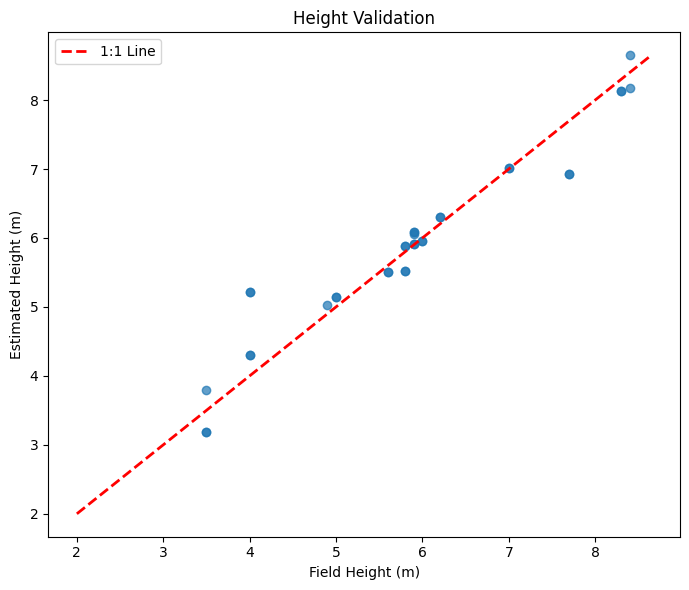

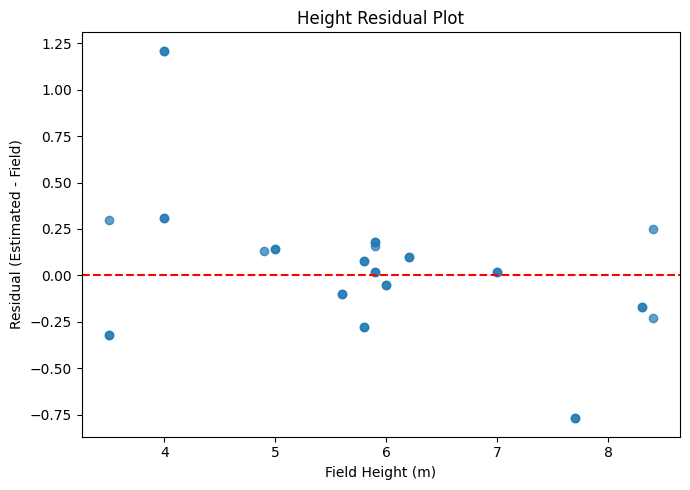

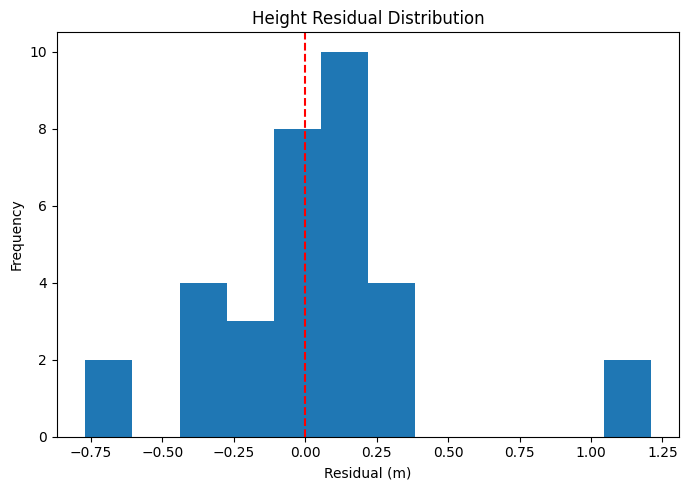

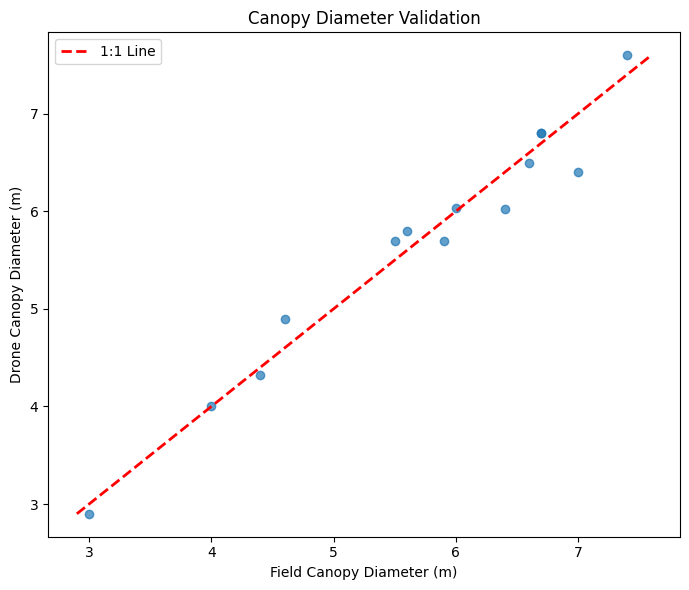

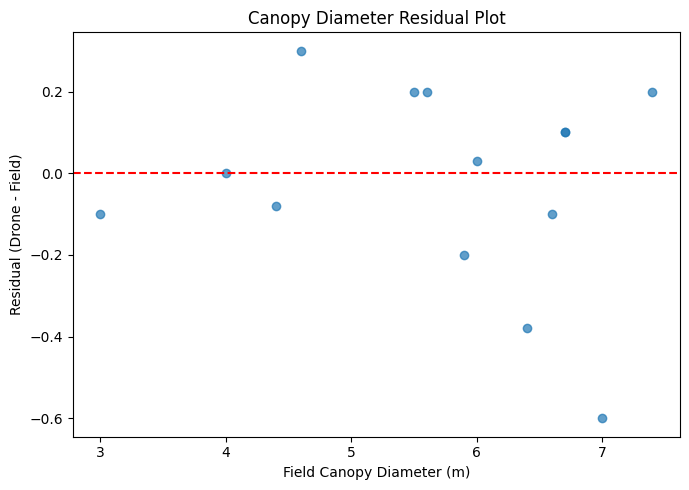

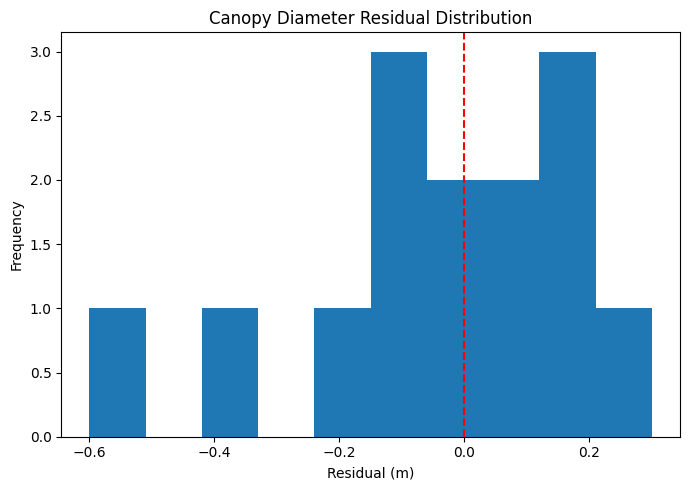

In [70]:
# -----------------------------
# Residual Calculation
# -----------------------------

# Height residuals
gdf_26["height_residual"] = gdf_26["hmax"] - gdf_26["val_height"]

# Canopy area residuals
gdf_26["area_residual"] = gdf_26["canopy_area"] - gdf_26["canopy_area_gt"]

# -----------------------------
# HEIGHT VALIDATION
# -----------------------------

fig, ax = plt.subplots(figsize=(7,6))

ax.scatter(gdf_26["val_height"], gdf_26["hmax"], alpha=0.7)

# 1:1 Line
min_val = min(gdf_26["val_height"].min(), gdf_26["hmax"].min())
max_val = max(gdf_26["val_height"].max(), gdf_26["hmax"].max())

ax.plot([min_val, max_val],
        [min_val, max_val],
        'r--',
        linewidth=2,
        label="1:1 Line")

ax.set_xlabel("Field Height (m)")
ax.set_ylabel("Estimated Height (m)")
ax.set_title("Height Validation")
ax.legend()

plt.tight_layout()
plt.show()

# -----------------------------
# HEIGHT RESIDUALS
# -----------------------------

fig, ax = plt.subplots(figsize=(7,5))

ax.scatter(gdf_26["val_height"], gdf_26["height_residual"], alpha=0.7)

ax.axhline(0,
           color='red',
           linestyle='--')

ax.set_xlabel("Field Height (m)")
ax.set_ylabel("Residual (Estimated - Field)")
ax.set_title("Height Residual Plot")

plt.tight_layout()
plt.show()

# -----------------------------
# HEIGHT RESIDUAL HISTOGRAM
# -----------------------------

fig, ax = plt.subplots(figsize=(7,5))

ax.hist(gdf_26["height_residual"],
        bins=12)

ax.axvline(0,
           color='red',
           linestyle='--')

ax.set_xlabel("Residual (m)")
ax.set_ylabel("Frequency")
ax.set_title("Height Residual Distribution")

plt.tight_layout()
plt.show()

# -----------------------------
# CANOPY DIAMETER VALIDATION
# -----------------------------

# Residuals
canopy_diam_df["diameter_residual"] = (
    canopy_diam_df["canopy_diameter"]
    - canopy_diam_df["val_canopy_diameter"]
)

# -----------------------------
# CANOPY DIAMETER VALIDATION
# -----------------------------

fig, ax = plt.subplots(figsize=(7,6))

ax.scatter(
    canopy_diam_df["val_canopy_diameter"],
    canopy_diam_df["canopy_diameter"],
    alpha=0.7
)

min_val = min(
    canopy_diam_df["val_canopy_diameter"].min(),
    canopy_diam_df["canopy_diameter"].min()
)

max_val = max(
    canopy_diam_df["val_canopy_diameter"].max(),
    canopy_diam_df["canopy_diameter"].max()
)

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label="1:1 Line"
)

ax.set_xlabel("Field Canopy Diameter (m)")
ax.set_ylabel("Drone Canopy Diameter (m)")
ax.set_title("Canopy Diameter Validation")
ax.legend()

plt.tight_layout()
plt.show()


# -----------------------------
# DIAMETER RESIDUALS
# -----------------------------

fig, ax = plt.subplots(figsize=(7,5))

ax.scatter(
    canopy_diam_df["val_canopy_diameter"],
    canopy_diam_df["diameter_residual"],
    alpha=0.7
)

ax.axhline(
    0,
    color='red',
    linestyle='--'
)

ax.set_xlabel("Field Canopy Diameter (m)")
ax.set_ylabel("Residual (Drone - Field)")
ax.set_title("Canopy Diameter Residual Plot")

plt.tight_layout()
plt.show()


# -----------------------------
# DIAMETER RESIDUAL HISTOGRAM
# -----------------------------

fig, ax = plt.subplots(figsize=(7,5))

ax.hist(
    canopy_diam_df["diameter_residual"],
    bins=10
)

ax.axvline(
    0,
    color='red',
    linestyle='--'
)

ax.set_xlabel("Residual (m)")
ax.set_ylabel("Frequency")
ax.set_title("Canopy Diameter Residual Distribution")

plt.tight_layout()
plt.show()

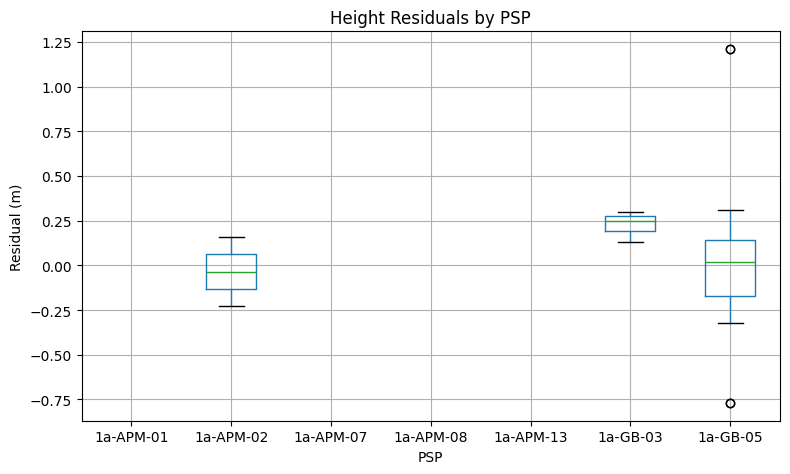

In [71]:
fig, ax = plt.subplots(figsize=(8,5))

gdf_26.boxplot(column="height_residual", by="psp", ax=ax)

ax.set_xlabel("PSP")
ax.set_ylabel("Residual (m)")
ax.set_title("Height Residuals by PSP")

plt.suptitle("")
plt.tight_layout()
plt.show()